## FFT de la señal senoidal

En las evidencias anteriores trabajé siempre en el **dominio del tiempo**. Ahora paso al **dominio de la frecuencia** calculando la Transformada Discreta de Fourier (DFT) de la senoidal, usando el algoritmo **FFT** de `numpy`.

La DFT de una señal de N muestras se define como:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j 2\pi \frac{k n}{N}} \qquad k = 0, 1, \dots, N-1$$

Cada índice `k` corresponde a una frecuencia física:

$$f_k = k \cdot \Delta f \qquad \text{con} \qquad \Delta f = \frac{f_s}{N}$$

donde $\Delta f$ es la **resolución espectral**: la mínima separación en frecuencia que el análisis puede distinguir.

Lo que espero ver: como una senoidal pura tiene toda su energía concentrada en una única frecuencia, su espectro debería ser un par de **deltas** (una en $+f_0$ y otra en $-f_0$) y cero en el resto.

### Paso 1

Importación de las librerías a utilizar.

In [46]:
import numpy as np
import matplotlib.pyplot as plt

### Paso 2

Reutilizo la función *mi_funcion_sen()* de las evidencias anteriores.

In [47]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = (np.arange(nn) / fs).reshape(nn, 1)
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

### Paso 3: función para calcular la FFT

Armo una función que envuelve a `np.fft.fft()` y que devuelve directamente el **eje de frecuencias en Hz** junto con el espectro, para no tener que recalcular a mano el $\Delta f$ cada vez.

Dos detalles de implementación:

- Las señales que genero vienen como vectores columna `(N, 1)`, así que las aplano con `.flatten()` antes de transformar.
- Divido el resultado por N. `np.fft.fft()` no normaliza, con lo cual el módulo crece con la cantidad de muestras; dividiendo por N el valor de cada delta queda independiente de N y se puede leer directamente como amplitud.

In [48]:
def mi_funcion_fft(xx, fs=1000):
    """FFT de xx con su eje de frecuencias en Hz.

    Devuelve:
      ff : frecuencias [Hz], de 0 a fs-df (las mayores a fs/2 son las negativas)
      XX : espectro complejo normalizado por N
    """
    xx = np.asarray(xx).flatten()
    nn = xx.size
    XX = np.fft.fft(xx) / nn
    ff = np.fft.fftfreq(nn, d=1 / fs)
    return ff, XX

### Paso 4: espectro de la senoidal

Genero la senoidal con los mismos parámetros de siempre y le calculo la FFT.

Elijo `ff = 4` Hz (el ejemplo visto en clase) con `N = 1000` y `fs = 1000` Hz, lo que da $\Delta f = f_s/N = 1$ Hz. Como 4 Hz es múltiplo exacto de 1 Hz, la frecuencia de la señal **cae justo sobre un bin** de la DFT (el bin k = 4).

In [49]:
N  = 1000
fs = 1000
df = fs / N          # resolucion espectral

vmax = np.sqrt(2)    # senoidal de 1 W, como en la evidencia anterior
f0   = 4             # Hz

tt, xx = mi_funcion_sen(vmax=vmax, dc=0, ff=f0, ph=0, nn=N, fs=fs)
ff, XX = mi_funcion_fft(xx, fs=fs)

print(f'N                        = {N} muestras')
print(f'fs                       = {fs} Hz')
print(f'Resolucion espectral  df = fs/N = {df} Hz')
print(f'Frecuencia de la señal   = {f0} Hz  ->  bin k = f0/df = {int(f0/df)}')
print(f'Frecuencia de Nyquist    = {fs/2} Hz')

N                        = 1000 muestras
fs                       = 1000 Hz
Resolucion espectral  df = fs/N = 1.0 Hz
Frecuencia de la señal   = 4 Hz  ->  bin k = f0/df = 4
Frecuencia de Nyquist    = 500.0 Hz


### Paso 5: los valores del vector de la FFT

Antes de graficar nada, miro **los números crudos** que devuelve la FFT. Es la forma más directa de convencerse de qué hay adentro del vector.

Dos cosas para tener en cuenta:

- `XX` es un vector de **N números complejos** (`dtype = complex128`), uno por cada bin. No es un vector de amplitudes.
- El orden de los bines **no** es de menor a mayor frecuencia. `np.fft.fft()` devuelve primero las frecuencias positivas y después las negativas:

| Índice `k` | Frecuencia |
|---|---|
| `0` | 0 Hz (continua) |
| `1 ... N/2-1` | positivas, de $\Delta f$ a $f_s/2 - \Delta f$ |
| `N/2` | $f_s/2$ (Nyquist) |
| `N/2+1 ... N-1` | **negativas**, de $-f_s/2 + \Delta f$ a $-\Delta f$ |

Por eso la delta de $-f_0$ no aparece "antes del cero" sino al final del arreglo, en el índice $N - k$. Con $f_0 = 4$ Hz y $N = 1000$:

$$k = 4 \qquad \text{y} \qquad N - k = 1000 - 4 = 996$$

Esos son los dos únicos bines con energía. El 996 **es** el de $-4$ Hz.

In [50]:
print(f'Tipo de dato   XX.dtype = {XX.dtype}')
print(f'Longitud       XX.size  = {XX.size}   (= N)')
print()

# Busco los bines que realmente tienen energia (el resto es ruido numerico ~1e-16)
umbral = 1e-6
bines = np.where(np.abs(XX) > umbral)[0]

print(f'Bines con |X[k]| > {umbral}  ->  k = {bines}')
print(f'Frecuencias correspondientes   ->  {ff[bines]} Hz')

Tipo de dato   XX.dtype = complex128
Longitud       XX.size  = 1000   (= N)

Bines con |X[k]| > 1e-06  ->  k = [  4 996]
Frecuencias correspondientes   ->  [ 4. -4.] Hz


Ahora imprimo los valores del vector alrededor de cada uno de esos dos bines, para ver que en el resto efectivamente no hay nada.

In [51]:
def mostrar_bines(XX, ff, ks):
    """Tabla con el contenido del vector de la FFT en los bines indicados."""
    print(f'{"k":>5} | {"f [Hz]":>8} | {"X[k] (complejo)":>26} | {"|X[k]|":>10}')
    print('-' * 62)
    for k in ks:
        print(f'{k:>5} | {ff[k]:>+8.1f} | '
              f'{XX[k].real:>+11.3e} {XX[k].imag:>+11.3e}j | '
              f'{np.abs(XX[k]):>10.4f}')


print('--- Alrededor del bin 4 (frecuencias positivas) ---')
mostrar_bines(XX, ff, range(0, 9))
print()
print('--- Alrededor del bin 996 (frecuencias negativas) ---')
mostrar_bines(XX, ff, range(992, 1000))

--- Alrededor del bin 4 (frecuencias positivas) ---
    k |   f [Hz] |            X[k] (complejo) |     |X[k]|
--------------------------------------------------------------
    0 |     +0.0 |  +6.688e-18  +0.000e+00j |     0.0000
    1 |     +1.0 |  -5.238e-17  +1.186e-17j |     0.0000
    2 |     +2.0 |  -5.276e-18  +3.602e-17j |     0.0000
    3 |     +3.0 |  -1.085e-16  +1.041e-16j |     0.0000
    4 |     +4.0 |  -3.301e-16  -7.071e-01j |     0.7071
    5 |     +5.0 |  +9.353e-17  -1.271e-16j |     0.0000
    6 |     +6.0 |  -8.489e-18  -6.768e-17j |     0.0000
    7 |     +7.0 |  +2.322e-17  -4.358e-17j |     0.0000
    8 |     +8.0 |  +1.889e-18  -3.681e-17j |     0.0000

--- Alrededor del bin 996 (frecuencias negativas) ---
    k |   f [Hz] |            X[k] (complejo) |     |X[k]|
--------------------------------------------------------------
  992 |     -8.0 |  +1.889e-18  +3.681e-17j |     0.0000
  993 |     -7.0 |  +2.322e-17  +4.358e-17j |     0.0000
  994 |     -6.0 |  -8

Se ve que en el bin 4 y en el 996 el módulo vale $V_{max}/2 = 0.7071$, y en todos los demás queda en el orden de $10^{-16}$, que es el error de redondeo de punto flotante (o sea, cero).

También se puede verificar directamente la **simetría hermítica** $X[N-k] = X^*[k]$: los dos valores son conjugados, misma parte real y parte imaginaria opuesta.

In [52]:
k_pos = int(f0 / df)      # 4
k_neg = N - k_pos         # 996

print(f'XX[{k_pos}]   = {XX[k_pos]:.6f}   (f = {ff[k_pos]:+.1f} Hz)')
print(f'XX[{k_neg}] = {XX[k_neg]:.6f}   (f = {ff[k_neg]:+.1f} Hz)')
print()
print(f'Conjugado de XX[{k_pos}] = {np.conj(XX[k_pos]):.6f}')
print(f'¿Es igual a XX[{k_neg}]? -> {np.allclose(np.conj(XX[k_pos]), XX[k_neg])}')
print()
print(f'Suma de los modulos = {np.abs(XX[k_pos]) + np.abs(XX[k_neg]):.4f}  (= Vmax = {vmax:.4f})')

XX[4]   = -0.000000-0.707107j   (f = +4.0 Hz)
XX[996] = -0.000000+0.707107j   (f = -4.0 Hz)

Conjugado de XX[4] = -0.000000+0.707107j
¿Es igual a XX[996]? -> True

Suma de los modulos = 1.4142  (= Vmax = 1.4142)


### El valor crudo: $\pm j500$

Los valores que vengo mostrando ($\mp j\,0.7071$) son los de **mi** función, que divide por N. Si se llama directamente a `np.fft.fft()` **sin normalizar**, el módulo de cada delta es:

$$|X_{crudo}[k_0]| = \frac{N \cdot V_{max}}{2}$$

porque la sumatoria de la DFT acumula las N muestras. Con el caso de la clase, que usa una senoidal de **amplitud unitaria** ($V_{max} = 1$) y $N = 1000$:

$$\frac{1000 \cdot 1}{2} = 500 \qquad \Rightarrow \qquad X[4] = -j500 \qquad X[996] = +j500$$

Esos son exactamente los valores $-j500$ y $+j500$. Reproduzco el caso para verlo:

In [53]:
# Senoidal de amplitud 1 (el caso de la clase), sin normalizar la FFT
_, x_unit = mi_funcion_sen(vmax=1, dc=0, ff=f0, ph=0, nn=N, fs=fs)
X_crudo = np.fft.fft(x_unit.flatten())      # SIN dividir por N

print(f'X_crudo[{k_pos}]   = {X_crudo[k_pos]:.4f}')
print(f'X_crudo[{k_neg}] = {X_crudo[k_neg]:.4f}')
print(f'Valor teorico N*Vmax/2 = {N * 1 / 2:.1f}')
print()
print(f'Y dividiendo por N: {X_crudo[k_pos]/N:.4f} y {X_crudo[k_neg]/N:.4f}   (= Vmax/2 = 0.5)')

X_crudo[4]   = -0.0000-500.0000j
X_crudo[996] = -0.0000+500.0000j
Valor teorico N*Vmax/2 = 500.0

Y dividiendo por N: -0.0000-0.5000j y -0.0000+0.5000j   (= Vmax/2 = 0.5)


Las tres formas de escribir lo mismo, para no confundirse cuando aparecen números distintos para la misma señal:

| Convención | Valor de la delta | Depende de N |
|---|---|---|
| `np.fft.fft()` cruda | $N \cdot V_{max}/2$ | **sí** |
| Dividida por N (la que uso) | $V_{max}/2$ | no |
| Dividida por N y $\times 2$ (un lado) | $V_{max}$ | no |

Elegí dividir por N justamente para que el número que se lee en el gráfico sea la amplitud de la señal y no dependa de cuántas muestras haya tomado. Con el vector crudo, la misma senoidal de 4 Hz daría 500 con N = 1000 y 250 con N = 500, aunque la señal sea idéntica.

### Paso 6: espectro de dos lados

Grafico el módulo $|X[k]|$ contra la frecuencia. Uso `np.fft.fftshift()` para reordenar el vector y que las frecuencias negativas queden a la izquierda del cero (`np.fft.fft` las devuelve al final del arreglo).

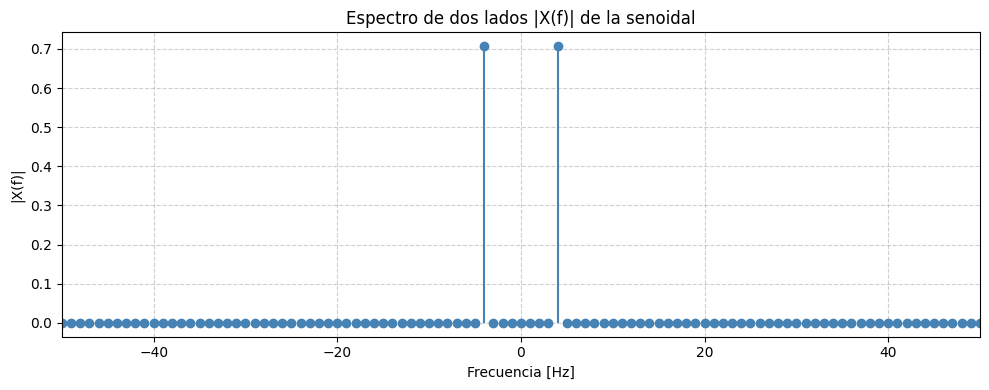

In [54]:
plt.figure(figsize=(10, 4))
plt.stem(np.fft.fftshift(ff), np.abs(np.fft.fftshift(XX)),
         linefmt='steelblue', markerfmt='o', basefmt=' ')
plt.title('Espectro de dos lados |X(f)| de la senoidal')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|X(f)|')
plt.xlim([-50, 50])   # zoom alrededor del origen para ver las deltas
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Paso 7: espectro de un lado y verificación de amplitud

Como la señal es **real**, el espectro es simétrico (hermítico): $X[-k] = X^*[k]$. Por eso la mitad negativa no aporta información nueva y alcanza con graficar de 0 a $f_s/2$.

Al quedarme con medio espectro, la energía de la delta negativa "se pierde", así que multiplico por 2 para que la delta valga la amplitud real de la senoidal:

$$|X(f_0)| = \frac{V_{max}}{2} \quad \text{(dos lados)} \qquad \Rightarrow \qquad 2 \cdot |X(f_0)| = V_{max} \quad \text{(un lado)}$$

Pico en el bin k         = 4
Frecuencia del pico      = 4.0000 Hz   (teorica: 4 Hz)
Amplitud del pico        = 1.4142 V    (teorica Vmax = 1.4142 V)
|X| en dos lados         = 0.7071      (teorica Vmax/2 = 0.7071)
Maximo fuera de la delta = 3.65e-16 V  (deberia ser ~0)


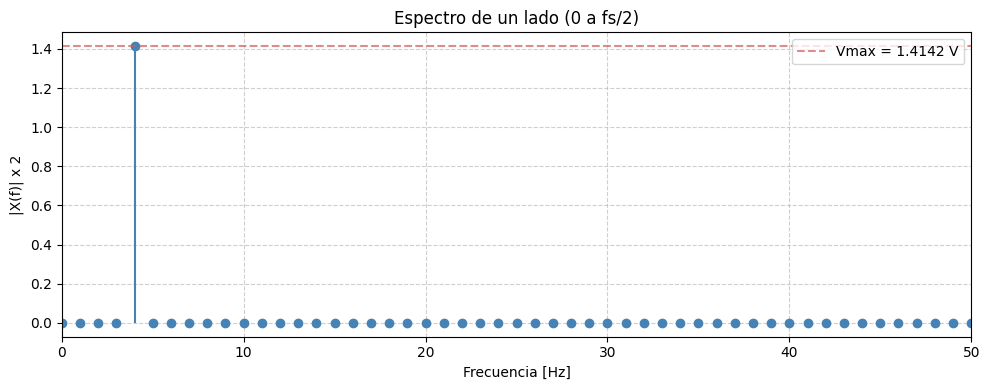

In [55]:
mitad   = N // 2
ff_pos  = ff[:mitad]
XX_pos  = 2 * np.abs(XX[:mitad])   # x2 por quedarme con medio espectro

# Busco la delta: el bin de mayor modulo
k_pico = np.argmax(XX_pos)

print(f'Pico en el bin k         = {k_pico}')
print(f'Frecuencia del pico      = {ff_pos[k_pico]:.4f} Hz   (teorica: {f0} Hz)')
print(f'Amplitud del pico        = {XX_pos[k_pico]:.4f} V    (teorica Vmax = {vmax:.4f} V)')
print(f'|X| en dos lados         = {np.abs(XX[k_pico]):.4f}      (teorica Vmax/2 = {vmax/2:.4f})')
print(f'Maximo fuera de la delta = {np.max(np.delete(XX_pos, k_pico)):.2e} V  (deberia ser ~0)')

plt.figure(figsize=(10, 4))
plt.stem(ff_pos, XX_pos, linefmt='steelblue', markerfmt='o', basefmt=' ')
plt.axhline(vmax, color='indianred', linestyle='--', alpha=0.7,
            label=f'Vmax = {vmax:.4f} V')
plt.title('Espectro de un lado (0 a fs/2)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|X(f)| x 2')
plt.xlim([0, 50])
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Paso 8: el mismo espectro en dB

En escala lineal el resto del espectro parece exactamente cero. Para ver qué hay realmente ahí paso a decibeles:

$$|X(f)|_{dB} = 20 \log_{10}|X(f)|$$

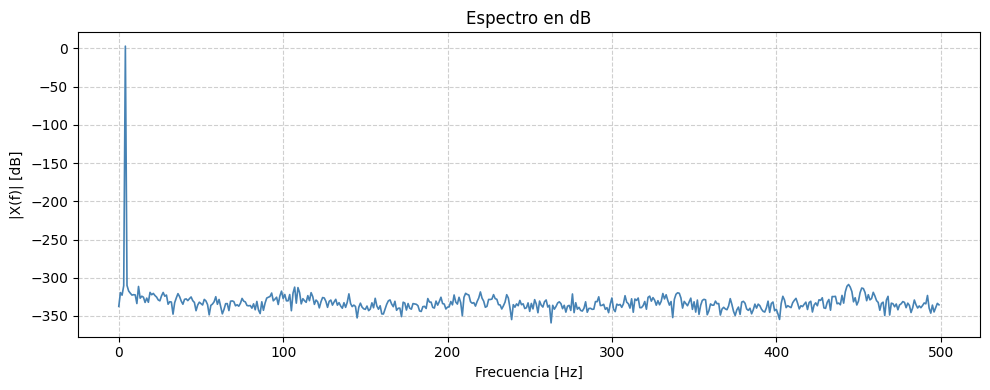

Nivel de la delta        = 3.01 dB
Piso de ruido numerico   = -308.76 dB


In [56]:
XX_db = 20 * np.log10(XX_pos + 1e-20)   # el epsilon evita log10(0)

plt.figure(figsize=(10, 4))
plt.plot(ff_pos, XX_db, linewidth=1.2, color='steelblue')
plt.title('Espectro en dB')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|X(f)| [dB]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f'Nivel de la delta        = {XX_db[k_pico]:.2f} dB')
print(f'Piso de ruido numerico   = {np.max(np.delete(XX_db, k_pico)):.2f} dB')

### Paso 9: parte real, parte imaginaria y fase

En los gráficos anteriores las dos deltas apuntan **para arriba**, pero eso es una consecuencia de estar graficando el **módulo**: $|X[k]| = \sqrt{\text{Re}^2 + \text{Im}^2}$ es no negativo por definición, así que al tomarlo se pierde el signo.

La DFT devuelve números **complejos**, y ahí sí aparece la antisimetría. Escribiendo la senoidal con Euler:

$$\sin(2\pi f_0 t) = \frac{e^{j 2\pi f_0 t} - e^{-j 2\pi f_0 t}}{2j}$$

se ve que las dos exponenciales entran con **signo opuesto**, con lo cual el espectro de la senoidal queda:

$$X(f_0) = -j\frac{V_{max}}{2} \qquad X(-f_0) = +j\frac{V_{max}}{2}$$

O sea: parte real nula y parte imaginaria $\mp V_{max}/2$. Ahí está la delta para abajo y la delta para arriba.

Esto es el caso general para cualquier señal real, que cumple la **simetría hermítica** $X[-k] = X^*[k]$:

| Componente | Simetría | Senoidal (seno) |
|---|---|---|
| Parte real | **par** | nula |
| Parte imaginaria | **impar** | $\mp V_{max}/2$ (una arriba, otra abajo) |
| Módulo | **par** | $V_{max}/2$ en ambas |
| Fase | **impar** | $\mp \pi/2$ |

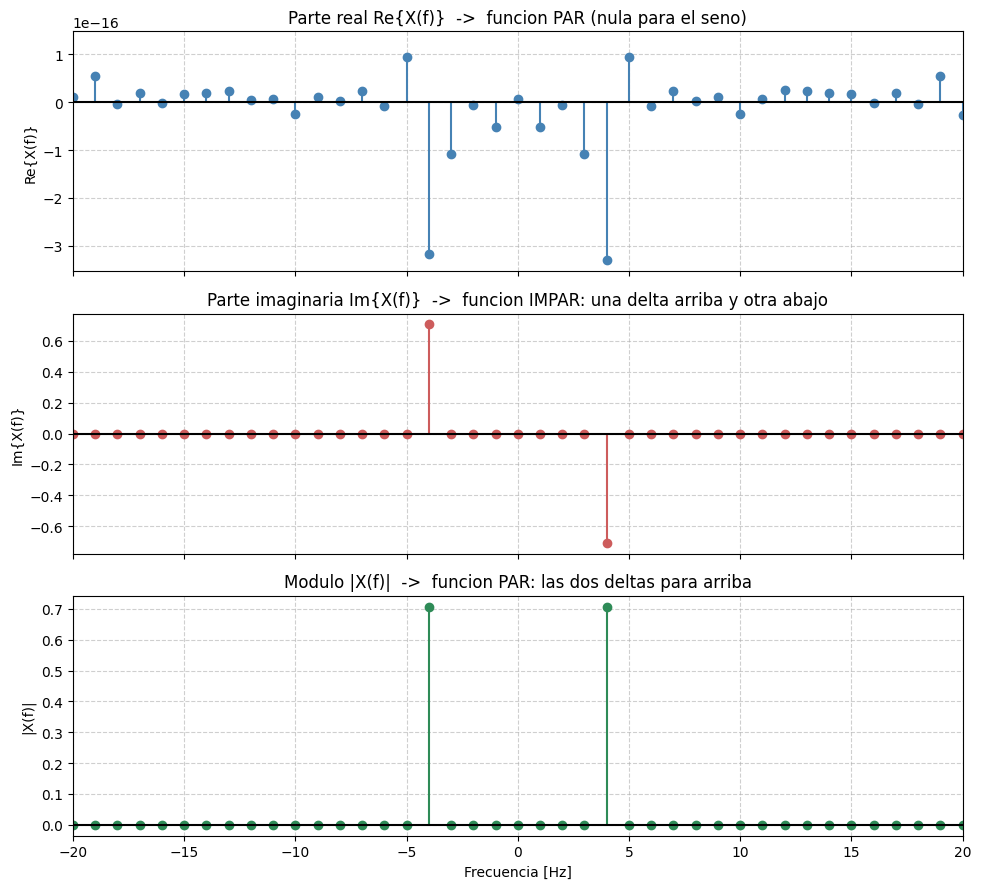

X(+f0) = -0.0000-0.7071j   ->  Im = -0.7071  (teorico: -0.7071)
X(-f0) = -0.0000+0.7071j   ->  Im = +0.7071  (teorico: +0.7071)
Suma de las partes imaginarias = -1.11e-16  (se cancelan)


In [57]:
XX_shift = np.fft.fftshift(XX)
ff_shift = np.fft.fftshift(ff)

fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axs[0].stem(ff_shift, np.real(XX_shift), linefmt='steelblue', markerfmt='o', basefmt='k-')
axs[0].set_title('Parte real Re{X(f)}  ->  funcion PAR (nula para el seno)')
axs[0].set_ylabel('Re{X(f)}')

axs[1].stem(ff_shift, np.imag(XX_shift), linefmt='indianred', markerfmt='o', basefmt='k-')
axs[1].set_title('Parte imaginaria Im{X(f)}  ->  funcion IMPAR: una delta arriba y otra abajo')
axs[1].set_ylabel('Im{X(f)}')

axs[2].stem(ff_shift, np.abs(XX_shift), linefmt='seagreen', markerfmt='o', basefmt='k-')
axs[2].set_title('Modulo |X(f)|  ->  funcion PAR: las dos deltas para arriba')
axs[2].set_ylabel('|X(f)|')
axs[2].set_xlabel('Frecuencia [Hz]')

for ax in axs:
    ax.set_xlim([-20, 20])
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f'X(+f0) = {XX[k_pico]:.4f}   ->  Im = {np.imag(XX[k_pico]):+.4f}  (teorico: {-vmax/2:+.4f})')
print(f'X(-f0) = {XX[-k_pico]:.4f}   ->  Im = {np.imag(XX[-k_pico]):+.4f}  (teorico: {+vmax/2:+.4f})')
print(f'Suma de las partes imaginarias = {np.imag(XX[k_pico]) + np.imag(XX[-k_pico]):.2e}  (se cancelan)')

### La fase

La otra forma de ver el mismo signo es mirando la **fase** del espectro, $\arg(X[k])$, que también es impar. La grafico solamente en los bines donde hay energía, porque en los demás el módulo es del orden de $10^{-16}$ y la fase es ruido numérico sin sentido físico.

Comparo el seno contra el coseno: son la misma señal desplazada 90°, tienen **exactamente el mismo módulo**, y toda la diferencia entre ellas está guardada en la fase.

--- seno ---
  f =   +4.0 Hz : Re = -0.0000  Im = -0.7071  |X| = 0.7071  fase =  -90.00°
  f =   -4.0 Hz : Re = -0.0000  Im = +0.7071  |X| = 0.7071  fase =  +90.00°

--- coseno ---
  f =   +4.0 Hz : Re = +0.7071  Im = -0.0000  |X| = 0.7071  fase =   -0.00°
  f =   -4.0 Hz : Re = +0.7071  Im = +0.0000  |X| = 0.7071  fase =   +0.00°



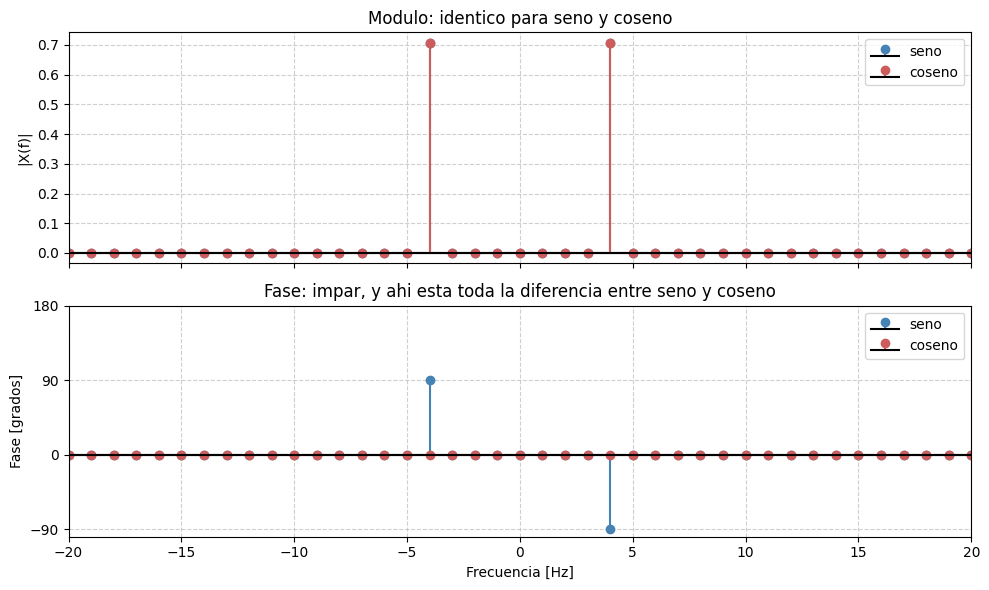

In [58]:
umbral = 1e-6   # solo miro los bines con energia real

for nombre, fase_extra in [('seno', 0), ('coseno', np.pi/2)]:
    _, x_i = mi_funcion_sen(vmax=vmax, dc=0, ff=f0, ph=fase_extra, nn=N, fs=fs)
    _, X_i = mi_funcion_fft(x_i, fs=fs)

    print(f'--- {nombre} ---')
    for k in [k_pico, -k_pico]:
        f_k = ff[k]
        print(f'  f = {f_k:+6.1f} Hz : Re = {np.real(X_i[k]):+.4f}  '
              f'Im = {np.imag(X_i[k]):+.4f}  '
              f'|X| = {np.abs(X_i[k]):.4f}  '
              f'fase = {np.angle(X_i[k], deg=True):+7.2f}°')
    print()

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for nombre, fase_extra, color in [('seno', 0, 'steelblue'), ('coseno', np.pi/2, 'indianred')]:
    _, x_i = mi_funcion_sen(vmax=vmax, dc=0, ff=f0, ph=fase_extra, nn=N, fs=fs)
    _, X_i = mi_funcion_fft(x_i, fs=fs)
    X_i_s = np.fft.fftshift(X_i)

    mod = np.abs(X_i_s)
    fase = np.where(mod > umbral, np.angle(X_i_s, deg=True), 0)  # enmascaro el ruido numerico

    axs[0].stem(ff_shift, mod, linefmt=color, markerfmt='o', basefmt='k-', label=nombre)
    axs[1].stem(ff_shift, fase, linefmt=color, markerfmt='o', basefmt='k-', label=nombre)

axs[0].set_title('Modulo: identico para seno y coseno')
axs[0].set_ylabel('|X(f)|')
axs[0].legend(loc='upper right')

axs[1].set_title('Fase: impar, y ahi esta toda la diferencia entre seno y coseno')
axs[1].set_ylabel('Fase [grados]')
axs[1].set_xlabel('Frecuencia [Hz]')
axs[1].set_yticks([-90, 0, 90, 180])
axs[1].legend(loc='upper right')

for ax in axs:
    ax.set_xlim([-20, 20])
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Paso 10: verificación con Parseval

El teorema de Parseval dice que la energía se conserva entre los dos dominios. En su versión discreta y usando la FFT normalizada por N que devuelve mi función:

$$P_x = \frac{1}{N}\sum_{n=0}^{N-1} |x[n]|^2 = \sum_{k=0}^{N-1} |X[k]|^2$$

Es una buena forma de controlar que la normalización esté bien hecha: la potencia calculada en el tiempo tiene que dar lo mismo que la calculada en frecuencia.

In [59]:
Px_tiempo     = np.mean(xx ** 2)
Px_frecuencia = np.sum(np.abs(XX) ** 2)

print(f'Potencia en el tiempo      = {Px_tiempo:.6f} W')
print(f'Potencia en la frecuencia  = {Px_frecuencia:.6f} W')
print(f'Diferencia                 = {abs(Px_tiempo - Px_frecuencia):.2e} W')
print()
# La potencia se reparte por igual entre las dos deltas
print(f'Aporte de cada delta       = {np.abs(XX[k_pico])**2:.6f} W  (la mitad de Px)')

Potencia en el tiempo      = 1.000000 W
Potencia en la frecuencia  = 1.000000 W
Diferencia                 = 2.22e-16 W

Aporte de cada delta       = 0.500000 W  (la mitad de Px)


### Paso 11: cuando la frecuencia no cae sobre un bin

Hasta acá la delta salió perfecta porque 4 Hz es múltiplo exacto de $\Delta f = 1$ Hz, es decir que en la ventana de N muestras entra un **número entero de ciclos** (4 ciclos en 1 segundo).

Si elijo una frecuencia que no cae sobre ningún bin (por ejemplo 4.5 Hz), la senoidal ya no es periódica dentro de la ventana y la energía se desparrama sobre todos los bines vecinos. Esto se llama **desparramo espectral** (*spectral leakage*).

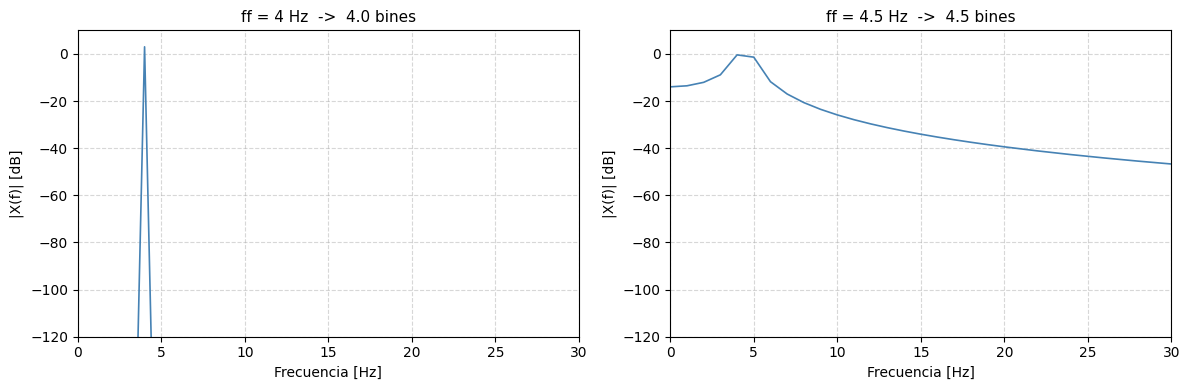

In [60]:
frecuencias = [4, 4.5]

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

for ax, f_i in zip(axs, frecuencias):
    _, xx_i = mi_funcion_sen(vmax=vmax, dc=0, ff=f_i, ph=0, nn=N, fs=fs)
    ff_i, XX_i = mi_funcion_fft(xx_i, fs=fs)

    XX_i_db = 20 * np.log10(2 * np.abs(XX_i[:mitad]) + 1e-20)

    ax.plot(ff_i[:mitad], XX_i_db, linewidth=1.2, color='steelblue')
    ax.set_title(f'ff = {f_i} Hz  ->  {f_i/df:.1f} bines', fontsize=11)
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('|X(f)| [dB]')
    ax.set_xlim([0, 30])
    ax.set_ylim([-120, 10])
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Análisis de resultados

- El espectro de la senoidal es efectivamente un par de **deltas** ubicadas en $\pm f_0 = \pm 4$ Hz, y el resto de los bines queda en el orden de $10^{-17}$, que es el error de redondeo de punto flotante. En el tiempo hacen falta las 1000 muestras para describir la señal; en frecuencia alcanza con esos dos valores.

- Aparecen **dos** deltas y no una porque la señal es real. La senoidal se puede escribir como suma de dos exponenciales complejas conjugadas ($\sin\theta = \frac{e^{j\theta} - e^{-j\theta}}{2j}$), una girando a $+f_0$ y otra a $-f_0$. Por eso cada delta vale $V_{max}/2$ y hay que multiplicar por 2 al quedarse con medio espectro.

- La amplitud recuperada del pico coincide con la $V_{max} = \sqrt{2}$ usada al generar la señal, lo que confirma que la normalización por N es la correcta.

- En el **módulo** las dos deltas apuntan para arriba porque $|X|$ es no negativo por definición. La delta "para abajo" está en la **parte imaginaria**, que para una señal real es una función **impar**: $\text{Im}\{X(+f_0)\} = -V_{max}/2$ y $\text{Im}\{X(-f_0)\} = +V_{max}/2$. Son justamente las dos exponenciales complejas de la identidad de Euler, que entran restándose. Al tomar módulo se descarta ese signo, que es la información de fase.

- Seno y coseno tienen **exactamente el mismo módulo**: solo se diferencian en la fase ($\mp 90°$ para el seno, $0°$ en ambas deltas para el coseno, porque el coseno es una función par y su espectro es puramente real). Por eso el espectro de módulo solo, aunque es lo que se grafica casi siempre, no alcanza para reconstruir la señal: hace falta el par módulo-fase, o equivalentemente parte real y parte imaginaria.

- La resolución espectral es $\Delta f = f_s/N = 1$ Hz. Depende **únicamente** del tiempo total de observación ($N/f_s = 1$ s): para afinar la resolución hay que medir más tiempo, no muestrear más rápido.

- Parseval se verifica con error del orden de $10^{-16}$, y se ve que cada delta aporta exactamente la mitad de la potencia total ($0.5$ W de la señal de 1 W).

- El caso de 4.5 Hz muestra el **desparramo espectral**: como la frecuencia cae justo entre dos bines, la energía se reparte entre todos y la delta se convierte en un lóbulo ancho con colas que decaen lentamente. La delta ideal aparece solamente cuando entra un número entero de ciclos en la ventana; en cualquier otro caso lo que se ve es la ventana rectangular implícita del muestreo.